(sec:nlo)=
# Multi-photon interactions

Multi-photon interactions describe the nonlinear responses of a molecular system to the simultaneous absorption or emission of two or more photons. These processes arise from higher‑order terms in the light–matter interaction and are governed by electronic transition pathways that do not appear in linear spectroscopy. Within the Born–Oppenheimer and electric‑dipole approximations, multi-photon effects are characterized by frequency‑dependent response functions—such as second‑ and third‑order polarizabilities—that encode resonant enhancements and selection rules beyond those of one‑photon transitions.

VeloxChem provides efficient tools for computing these nonlinear response properties at the levels of time‑dependent density functional theory (TDDFT) and the complex polarization propagator (CPP) aproach. By solving perturbation‑dependent response equations for multiple field frequencies, the program enables the evaluation of two‑photon absorption amplitudes, hyperpolarizabilities, and other nonlinear optical indicators relevant to multi-photon spectroscopies.

(sec:tpa)=
## Two-photon absorption

### TPA strengths

In the quadratic response theory framework, two‑photon absorption (TPA) spectra are determined from residues of the second‑order response function at half the excitation energy. TPA strengths factorize into products of transition moments, which quantify the effective coupling of the ground state to an excited state via the simultaneous interaction with two photons. The two-photon transition moment is given by the sum-over-states expression

$$
S^{f\leftarrow 0}_{\alpha\beta} = \frac{1}{\hbar}
\sum_{n} 
\Bigg[
    \frac{ 
         \langle 0 | \hat{\mu}_\alpha| n \rangle
         \langle n |\hat{\mu}_\beta | f \rangle  
         }{
         \omega_{n0}-\omega_{f0}/2
         } 
    +
    \frac{
        \langle 0 | \hat{\mu}_\beta| n \rangle 
        \langle n |\hat{\mu}_\alpha | f \rangle
        }{
        \omega_{n0}-\omega_{f0}/2
        }
    \Bigg]
$$

where $\hbar \omega_{n0}$  is the excitation energy for state $|n\rangle$, $\hat{\mu}_\alpha$ is the electric dipole moment operator along the Cartesian axis $\alpha$ , and the summation includes the ground state, $| n \rangle = | 0 \rangle$.

For an isotropic sample, the experimentally relevant TPA strengths are obtained from the orientational average of the squared magnitudes of the Cartesian transition moments. This averaging yields a scalar measure that captures the laser field polarization, and it provides the quantity directly comparable to measured TPA cross sections, see {cite}`Norman2018` for further details.

$$
\delta_f^\mathrm{TPA} = 
\frac{1}{15}
\sum_{\alpha, \beta}
\left(
2 S^{f\leftarrow 0}_{\alpha\beta} \big[S^{f\leftarrow 0}_{\alpha\beta}\big]^* +
S^{f\leftarrow 0}_{\alpha\alpha} \big[S^{f\leftarrow 0}_{\beta\beta}\big]^*
\right)
$$

We have here assumed an experimental single-beam, monochromatic, setup with linear polarization.

The TPA strength for a given state $|f\rangle$ contributes to the spectrum observable cross section, $\sigma(\omega)$, according to

$$
\sigma(\omega) = 
\frac{4 \pi^3 \alpha a_0^5 \omega^2}{c} 
\; \delta_f^\mathrm{TPA}
\; g(2\omega, \omega_{f0}, \gamma)
$$

where $\alpha$ is the fine structure constant, $a_0$ is the Bohr radius, $c$ is the speed of light, and $g$ is a line broadening function with unit area centered at half the transition angular frequency $\omega_{f0}/2$ and dependent on the dampening parameter $\gamma$. Specific for the Lorentzian broadening function, its value at a TP resonance frequency ($2 \omega = \omega_{f0}$) is equal to

$$
L(\omega_{f0}) = \frac{1}{\pi \gamma}
$$

The unit of the cross section will be GM (after [Maria Göppert-Mayer](https://sv.wikipedia.org/wiki/Maria_Goeppert-Mayer)) given that atomic units is used for $\omega$, $\delta_f^\mathrm{TPA}$, and $g$ and SI units is used for the rest, and that a multiplication by a factor of $10^{58}$ is made to account for the fact that 1 GM corresponds to $10^{-50}$ cm$^4$s photon$^{-1}$.

TPA simulations are sensitive toward the choice of basis set and exchange-correlation functional. The inclusion of diffuse functions in the basis set is typically required, and in regard with functionals, it has been demonstrated that the range-separated hybrid CAM-B3LYP and the hybrid meta-GGA MN15 functionals are good choices, see {cite}`ahmadzadeh_2024`.

**Python script**

In [1]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("para-nitroaniline")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

tpa_drv = vlx.TpaTransitionDriver()

tpa_drv.nstates = 5
tpa_results = tpa_drv.compute(molecule, basis, scf_results)


                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [3]:
tpa_drv.print_results(tpa_results, section="summary")

                                                                                                                          
                                                  TPA Transition Summary                                                  
              ----------------------------------------------------------------------------------------------              
              State        Photon Energy          Linear TPA        Circular TPA     Osc. Strength                        
              ----------------------------------------------------------------------------------------------              
              1          1.472774 eV      0.010167            0.015251          0.000000                                  
              2          1.923271 eV      0.101851            0.152777          0.000138                                  
              3          2.091274 eV   2011.763815         1498.996500          0.413475                                  
              4 

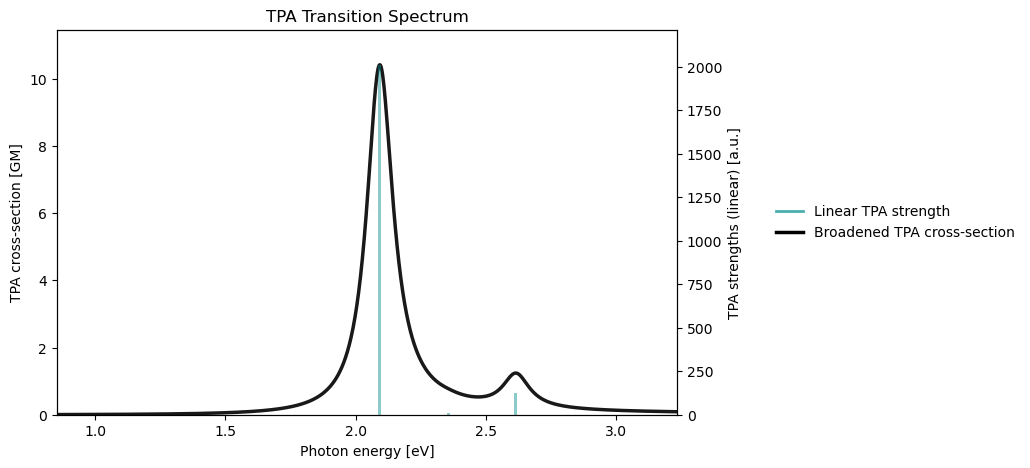

In [4]:
tpa_drv.plot_spectrum(
    tpa_results,
    x_unit="ev",
    broadening_value=0.123984,
    broadening_unit="ev",
)

In [5]:
molecule.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
xcfun: MN15
basis: def2-svpd
@end

@response
property: tpa transition
nstates: 10
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

(sec:tpacs)=
### TPA cross section

An alternative route to two-photon absorption spectra is provided by **complex cubic response theory**, in which the response equations are solved in the presence of a phenomenological damping parameter. Rather than evaluating individual two-photon transition moments and constructing the spectrum from discrete transitions, the absorption profile is obtained directly from the imaginary part of the frequency-dependent **second hyperpolarizability**. In this formulation, the TPA spectrum is proportional to

$$
\sigma(\omega) =
\frac{4 \pi^2 \alpha a_0^5 \omega^2}{c} 
\;
\mathrm{Im}
\big[
\overline{\gamma}(-\omega;\omega,-\omega,\omega)
\big]
$$

where $\alpha$ is the fine structure constant, $a_0$ is the Bohr radius, $c$ is the speed of light, $\omega$ is the photon frequency, and $\overline{\gamma}$ denotes the orientationally averaged second hyperpolarizability associated with the intensity-dependent refractive index (IDRI) process. The damping parameter introduces lifetime broadening and yields a continuous spectral lineshape without the explicit evaluation of excited-state residues. Complex response theory therefore provides an efficient framework for simulating TPA spectra over broad frequency ranges and in regions containing multiple closely spaced resonances.

In [6]:
import veloxchem as vlx
import numpy as np

molecule = vlx.Molecule.read_name("para-nitroaniline")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

tpa_drv = vlx.TpaDriver()

tpa_drv.frequencies = np.arange(0.05, 0.11, 0.0025) 

tpa_results = tpa_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [7]:
tpa_drv.print_results(tpa_results, section="summary")

                                                                                                                          
                                                   Reduced TPA Summary                                                    
      --------------------------------------------------------------------------------------------------------------      
      Photon Energy[a.u.] Photon Energy[eV]         Re(gamma)         Im(gamma)   TPA cross-section[GM]                   
      --------------------------------------------------------------------------------------------------------------      
      0.0500                       1.36057    31675.73519989     3239.01167689              0.03228959                    
      0.0525                       1.42860    35530.36111436     3961.68618474              0.04354203                    
      0.0550                       1.49663    40265.59950941     4932.71867318              0.05950066                    
      0.0575    

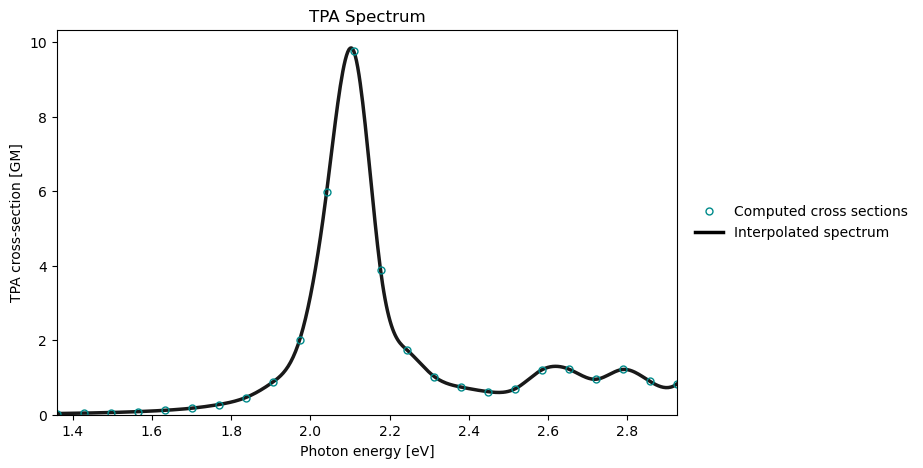

In [8]:
tpa_drv.plot_spectrum(
    tpa_results,
    x_unit="ev",
)

We note that this spectrum is in perfect agreement with that presented above based on TP strengths, and which of the two approaches that is computationally preferable depends on the application at hand. 

:::{code}
@jobs
task: response
@end

@method settings
xcfun: MN15
basis: def2-svpd
@end

@response
property: tpa
frequencies: 0.3-0.5 (0.1)
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::